# Q1 What is a Common Table Expression (CTE), and how does it improve SQL query readability?

## ANS:- A Common Table Expression (CTE) is a temporary result set defined using the WITH clause. It helps make complex SQL queries easier to read, understand, and maintain by breaking them into smaller logical parts. A CTE can also be reused within the same query.
 A CTE is a temporary result set created using the WITH clause. It improves readability and simplifies complex queries

## SQL QUERY

In [ ]:
WITH ProductData AS (
    SELECT ProductID, ProductName, Price
    FROM Products
)
SELECT * FROM ProductData;

### OUT PUT
with highsalary as(
select*
from employees
where salary >50000
)
select* from highsalary;
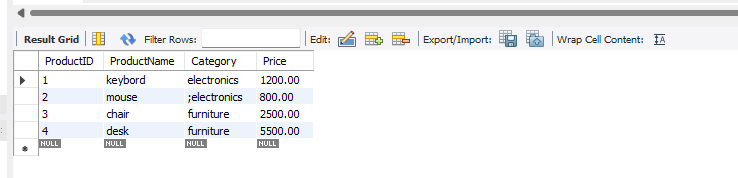

# Q2 Why are some views updatable while others are read-only? Explain with an example.

## ANS:- A view based on a single table is usually updatable. A view using GROUP BY, COUNT(), or joins is generally read-only.

## SQL QUERY

In [ ]:
CREATE VIEW ProductView AS
SELECT ProductID, ProductName, Price
FROM Products;

### OUT PUT
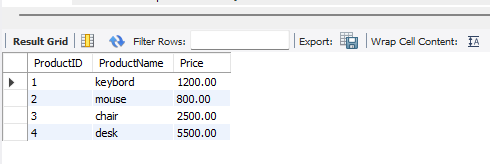

# Q3. What advantages do stored procedures offer compared to writing raw SQL queries repeatedly?

# Answer: Stored procedures reduce code duplication, improve performance, and increase security.

## SQL QUERY

In [ ]:
DELIMITER //

CREATE PROCEDURE GetAllProducts()
BEGIN
    SELECT * FROM Products;
END //

DELIMITER ;

### OUTPUT
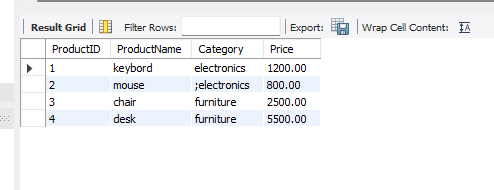

# Q4. What is the purpose of triggers in a database? Mention one use case where a trigger is essential.

## Answer: A trigger automatically executes when data is inserted, updated, or deleted.

In [ ]:
CREATE TABLE ProductLog (
    ProductID INT,
    DeletedDate DATETIME
);


DELIMITER //

CREATE TRIGGER ProductDeleteLog
AFTER DELETE ON Products
FOR EACH ROW
BEGIN
    INSERT INTO ProductLog
    VALUES (OLD.ProductID, NOW());
END //

DELIMITER ;

### OUTPUT
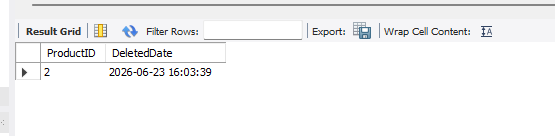

# Q5. Explain the need for data modelling and normalization when designing a database.

## Answer: Data Modeling is the process of designing the structure of a database, including tables, columns, relationships, and constraints. It helps organize data efficiently and ensures that the database meets business requirements.
Normalization is the process of organizing data into related tables to reduce redundancy and improve data integrity. It eliminates duplicate data and prevents anomalies during insert, update, and delete operations.

Benefits of Data Modeling and Normalization:
1)Reduces data duplication.
2)Improves data consistency and accuracy.
3)Maintains data integrity.
4)Makes database maintenance easier.
5)Improves storage efficiency and query performance.

Example: Instead of storing customer details repeatedly in an Orders table, create separate Customers and Orders tables and link them using a foreign key. This avoids duplicate customer information and keeps the database organized.

# Q6. Write a CTE to calculate the total revenue for each product
 (Revenues = Price × Quantity), and return only products where  revenue > 3000.

## SQL QUERY

In [ ]:
WITH ProductRevenue AS (
    SELECT
        p.ProductID,
        p.ProductName,
        SUM(p.Price * s.Quantity) AS Revenue
    FROM Products p
    JOIN Sales s
        ON p.ProductID = s.ProductID
    GROUP BY p.ProductID, p.ProductName
)
SELECT *
FROM ProductRevenue
WHERE Revenue > 3000;

### OUTPUT
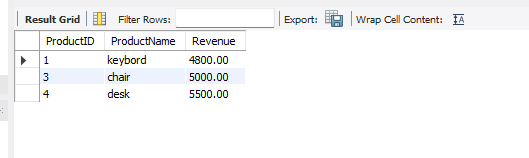

# Q7. Create a view named that shows:
 Category, TotalProducts, AveragePrice.

## SQL QUERY

In [ ]:
CREATE VIEW vw_CategorySummary AS
SELECT
    Category,
    COUNT(*) AS TotalProducts,
    AVG(Price) AS AveragePrice
FROM Products
GROUP BY Category;

SELECT * FROM vw_CategorySummary;

### OUTPUT
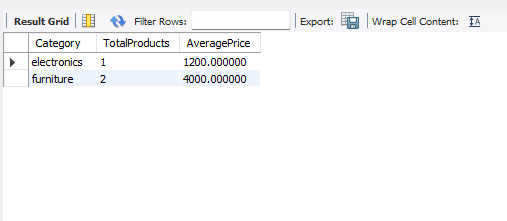

# Q8. Create an updatable view containing ProductID, ProductName, and Price.
 Then update the price of ProductID = 1 using the view.

## SQL QUERY

In [ ]:
CREATE VIEW ProductView AS
SELECT ProductID, ProductName, Price
FROM Products;

UPDATE ProductView
SET Price = 1500
WHERE ProductID = 1;

SELECT * FROM ProductView;

### OUTPUT
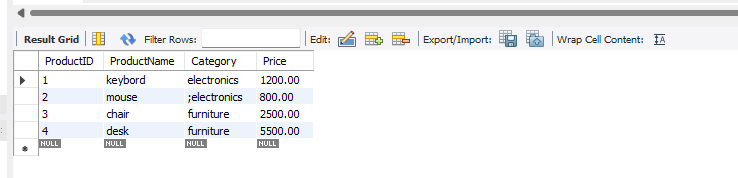

# Q9. Create a stored procedure that accepts a category name and returns all products belonging to that
category

## SQL QUERY

In [ ]:
DELIMITER //

CREATE PROCEDURE GetProductsByCategory(
    IN p_Category VARCHAR(50)
)
BEGIN
    SELECT *
    FROM Products
    WHERE Category = p_Category;
END //

DELIMITER ;

CALL GetProductsByCategory('Electronics');

### OUTPOT
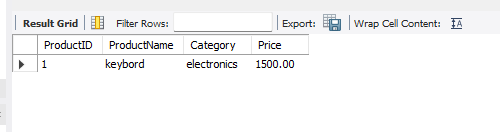

# .Q10 CREATE AN AFTER DELETING TRIGGER ON THE PRODUCTS TABLE THAT ARCHIVES THATA ARCHIVES DELETED PRODUCT ROWS INTO A NEW TABLE PRODUCTARCHIVE.THE ARCHIVE SHOULD STORE PRODUCTID, PRODUCTNAME,CATEGORY, PRICE,AND DELETEDAT TIMESTAMP.

## SQL QUERY

In [ ]:
CREATE TABLE ProductArchive (
    ProductID INT,
    ProductName VARCHAR(100),
    Category VARCHAR(50),
    Price DECIMAL(10,2),
    DeletedAt TIMESTAMP
);

DELIMITER //

CREATE TRIGGER trg_ProductArchive
AFTER DELETE ON Products
FOR EACH ROW
BEGIN
    INSERT INTO ProductArchive
    VALUES (
        OLD.ProductID,
        OLD.ProductName,
        OLD.Category,
        OLD.Price,
        NOW()
    );
END //

DELIMITER ;

DELETE FROM Sales WHERE ProductID = 1;
DELETE FROM Products WHERE ProductID = 1;

SELECT * FROM ProductArchive;


### OUTPUT
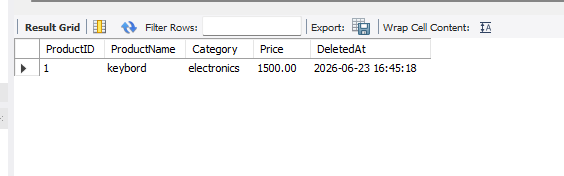